# ERA5 Temperature Analysis for Alaska Region

This notebook analyzes ERA5 monthly 2m temperature data for the Alaska region (50-62°N, 130-140°W) covering 1970-2025.

## Analysis includes:
1. JJAS (June-July-August-September) mean temperature comparison: 1970-1999 vs 2000-2025
2. October temperature timeseries for the entire domain and time period


In [26]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Load ERA5 Data

In [27]:
# Load the ERA5 zarr dataset
zarr_path = Path('../data/external/era5/era5_monthly_cds.zarr')

print(f"Loading ERA5 data from: {zarr_path}")
ds = xr.open_zarr(zarr_path)

print("Dataset overview:")
print(f"  Dimensions: {dict(ds.dims)}")
print(f"  Variables: {list(ds.data_vars.keys())}")
print(f"  Time range: {ds.time.min().values} to {ds.time.max().values}")
print(f"  Spatial extent:")
print(f"    Latitude: {ds.latitude.min().values:.2f}° to {ds.latitude.max().values:.2f}°N")
print(f"    Longitude: {ds.longitude.min().values:.2f}° to {ds.longitude.max().values:.2f}°E")

print(ds)

Loading ERA5 data from: ../data/external/era5/era5_monthly_cds.zarr
Dataset overview:
  Dimensions: {'time': 16500, 'latitude': 49, 'longitude': 41, 'step': 12}
  Variables: ['d2m', 'rsn', 'sd', 'sf', 'skt', 'slhf', 'sp', 'sshf', 'ssr', 'str', 't2m', 'tcsw', 'tp', 'u10', 'v10']
  Time range: 1969-12-31T18:00:00.000000000 to 2024-12-01T23:00:00.000000000
  Spatial extent:
    Latitude: 50.00° to 62.00°N
    Longitude: -140.00° to -130.00°E
<xarray.Dataset> Size: 11GB
Dimensions:     (time: 16500, latitude: 49, longitude: 41, step: 12)
Coordinates:
  * time        (time) datetime64[ns] 132kB 1969-12-31T18:00:00 ... 2024-12-0...
  * latitude    (latitude) float64 392B 62.0 61.75 61.5 ... 50.5 50.25 50.0
  * longitude   (longitude) float64 328B -140.0 -139.8 -139.5 ... -130.2 -130.0
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    number      int64 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 132kB dask.array<chunksize=(336,), met

In [28]:
# Extract 2m temperature and convert from Kelvin to Celsius
temp_2m = ds['t2m'] - 273.15  # Convert K to °C
temp_2m.attrs['units'] = '°C'
temp_2m.attrs['long_name'] = '2m Temperature'

print(f"2m Temperature data:")
print(f"  Shape: {temp_2m.shape}")
print(f"  Temperature range: {temp_2m.min().values:.1f}°C to {temp_2m.max().values:.1f}°C")

# Create monthly means by averaging over the 'step' dimension
temp_monthly = temp_2m
print(f"  Monthly means shape: {temp_monthly.shape}")

2m Temperature data:
  Shape: (16500, 49, 41)
  Temperature range: -43.3°C to 25.0°C
  Monthly means shape: (16500, 49, 41)
  Temperature range: -43.3°C to 25.0°C
  Monthly means shape: (16500, 49, 41)


## Prepare Time Filtering

In [29]:
# Create datetime index for easier filtering
time_dt = pd.to_datetime(temp_monthly.time.values)
temp_monthly = temp_monthly.assign_coords(time=time_dt)

# Define time periods
period1 = slice('1970', '1999')
period2 = slice('2000', '2025')

# Define JJAS months (June, July, August, September)
jjas_months = [6, 7, 8, 9]

print(f"Analysis periods:")
print(f"  Period 1: {period1.start} - {period1.stop}")
print(f"  Period 2: {period2.start} - {period2.stop}")
print(f"  JJAS months: {jjas_months}")

Analysis periods:
  Period 1: 1970 - 1999
  Period 2: 2000 - 2025
  JJAS months: [6, 7, 8, 9]


## 1. JJAS Temperature Analysis: 1970-1999 vs 2000-2025

In [30]:
# Filter for JJAS months
temp_jjas = temp_monthly.where(temp_monthly.time.dt.month.isin(jjas_months), drop=True)

# Calculate JJAS means for each period
temp_jjas_p1 = temp_jjas.sel(time=period1).mean(dim='time')
temp_jjas_p2 = temp_jjas.sel(time=period2).mean(dim='time')

# Calculate difference (warming)
temp_jjas_diff = temp_jjas_p2 - temp_jjas_p1

print(f"JJAS Temperature Statistics:")
print(f"  1970-1999 mean: {temp_jjas_p1.mean().values:.2f}°C")
print(f"  2000-2025 mean: {temp_jjas_p2.mean().values:.2f}°C")
print(f"  Mean warming: {temp_jjas_diff.mean().values:.2f}°C")
print(f"  Max warming: {temp_jjas_diff.max().values:.2f}°C")
print(f"  Min warming: {temp_jjas_diff.min().values:.2f}°C")

JJAS Temperature Statistics:
  1970-1999 mean: 10.37°C
  2000-2025 mean: 11.14°C
  Mean warming: 0.77°C
  Max warming: 1.90°C
  Min warming: 0.24°C


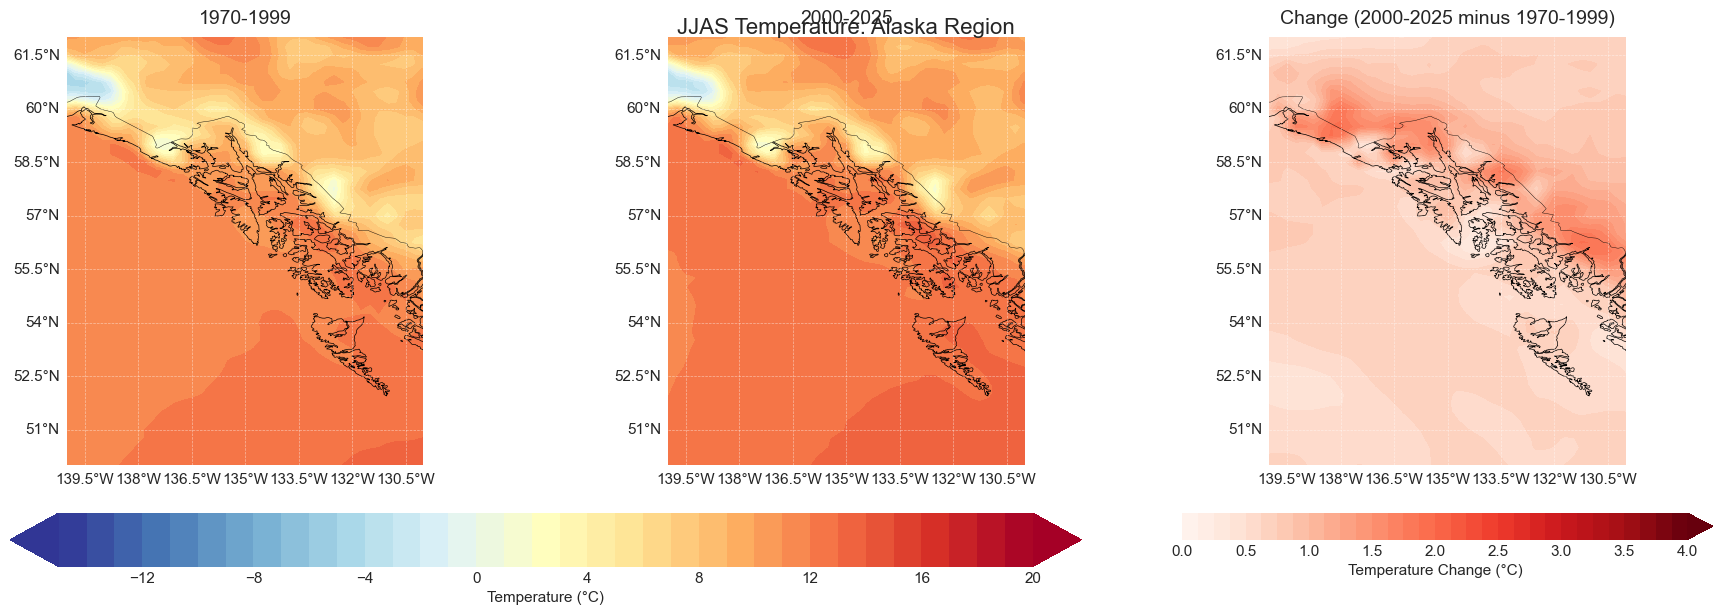

In [31]:
# Simple, clean JJAS temperature comparison maps
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig = plt.figure(figsize=(18, 6), layout='constrained')
proj = ccrs.PlateCarree()

# Simple, clean colormaps
temp_levels = np.linspace(-15, 20, 36)
diff_levels = np.linspace(0, 4, 33)

# Plot 1: 1970-1999
ax1 = fig.add_subplot(1, 3, 1, projection=proj)
ax1.coastlines(linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.3)
im1 = ax1.contourf(temp_jjas_p1.longitude, temp_jjas_p1.latitude, temp_jjas_p1, 
                   levels=temp_levels, cmap='RdYlBu_r', extend='both', transform=proj)
ax1.set_title('1970-1999', fontsize=14, pad=10)
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
gl1.top_labels = gl1.right_labels = False

# Plot 2: 2000-2025
ax2 = fig.add_subplot(1, 3, 2, projection=proj)
ax2.coastlines(linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.3)
im2 = ax2.contourf(temp_jjas_p2.longitude, temp_jjas_p2.latitude, temp_jjas_p2, 
                   levels=temp_levels, cmap='RdYlBu_r', extend='both', transform=proj)
ax2.set_title('2000-2025', fontsize=14, pad=10)
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
gl2.top_labels = gl2.right_labels = False

# Plot 3: Difference
ax3 = fig.add_subplot(1, 3, 3, projection=proj)
ax3.coastlines(linewidth=0.5)
ax3.add_feature(cfeature.BORDERS, linewidth=0.3)
im3 = ax3.contourf(temp_jjas_diff.longitude, temp_jjas_diff.latitude, temp_jjas_diff, 
                   levels=diff_levels, cmap='Reds', extend='max', transform=proj)
ax3.set_title('Change (2000-2025 minus 1970-1999)', fontsize=14, pad=10)
gl3 = ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
gl3.top_labels = gl3.right_labels = False

# Simple colorbars
plt.colorbar(im1, ax=[ax1, ax2], orientation='horizontal', pad=0.05, 
             label='Temperature (°C)', shrink=0.9)
plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, 
             label='Temperature Change (°C)', shrink=0.9)

plt.suptitle('JJAS Temperature: Alaska Region', fontsize=16, y=0.98)
plt.show()

## 2. October Temperature Timeseries Analysis

In [32]:
# Filter for October data
temp_october = temp_monthly.where(temp_monthly.time.dt.month == 10, drop=True)

# Calculate domain-wide average for each October
temp_october_mean = temp_october.mean(dim=['latitude', 'longitude'], skipna=True)

# Create annual timeseries
years = temp_october_mean.time.dt.year.values
temperatures = temp_october_mean.values

print(f"October Temperature Timeseries:")
print(f"  Number of years: {len(years)}")
print(f"  Year range: {years.min()} - {years.max()}")
print(f"  Temperature range: {temperatures.min():.2f}°C to {temperatures.max():.2f}°C")
print(f"  Mean temperature: {temperatures.mean():.2f}°C")

October Temperature Timeseries:
  Number of years: 1375
  Year range: 1970 - 2024
  Temperature range: nan°C to nan°C
  Mean temperature: nan°C


In [33]:
# Calculate trend analysis
from scipy import stats

# Linear trend for entire period
slope_all, intercept_all, r_value_all, p_value_all, std_err_all = stats.linregress(years, temperatures)
trend_all = slope_all * 10  # Per decade

# Linear trend for each period
mask_p1 = (years >= 1970) & (years <= 1999)
mask_p2 = (years >= 2000) & (years <= 2025)

slope_p1, intercept_p1, r_value_p1, p_value_p1, std_err_p1 = stats.linregress(years[mask_p1], temperatures[mask_p1])
slope_p2, intercept_p2, r_value_p2, p_value_p2, std_err_p2 = stats.linregress(years[mask_p2], temperatures[mask_p2])

trend_p1 = slope_p1 * 10  # Per decade
trend_p2 = slope_p2 * 10  # Per decade

print(f"\nTrend Analysis:")
print(f"  Entire period ({years.min()}-{years.max()}): {trend_all:.3f}°C/decade (p={p_value_all:.4f})")
print(f"  Period 1 (1970-1999): {trend_p1:.3f}°C/decade (p={p_value_p1:.4f})")
print(f"  Period 2 (2000-2025): {trend_p2:.3f}°C/decade (p={p_value_p2:.4f})")


Trend Analysis:
  Entire period (1970-2024): nan°C/decade (p=nan)
  Period 1 (1970-1999): nan°C/decade (p=nan)
  Period 2 (2000-2025): nan°C/decade (p=nan)


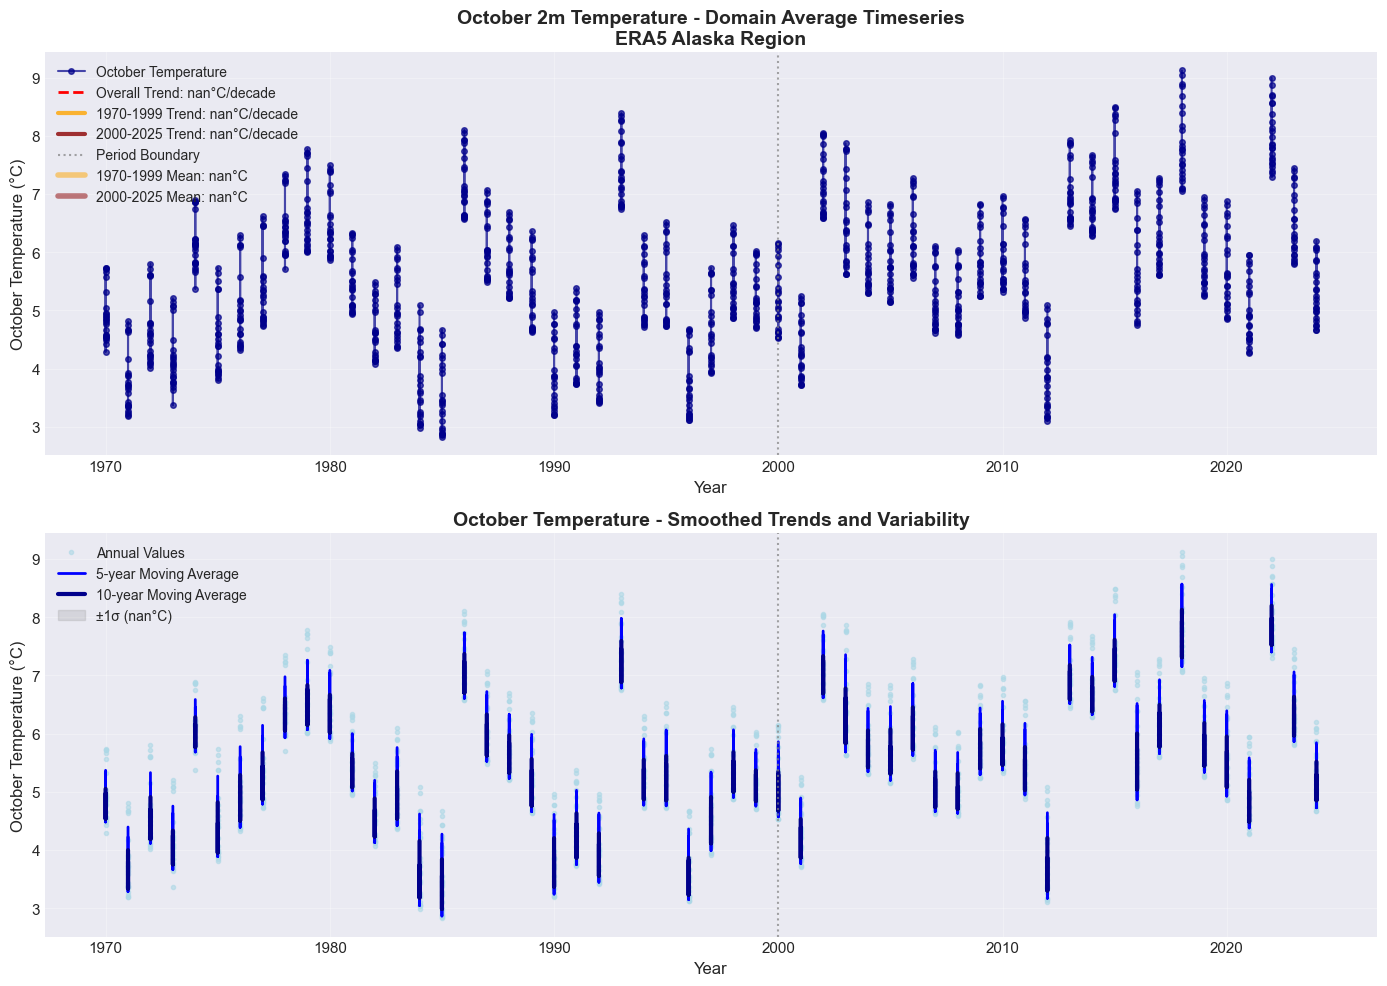

In [34]:
# Create October temperature timeseries plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Full timeseries with trends
ax1.plot(years, temperatures, 'o-', color='darkblue', alpha=0.7, markersize=4, linewidth=1.5, label='October Temperature')

# Add trend lines
trend_line_all = intercept_all + slope_all * years
ax1.plot(years, trend_line_all, '--', color='red', linewidth=2, 
         label=f'Overall Trend: {trend_all:.3f}°C/decade')

# Period-specific trends
trend_line_p1 = intercept_p1 + slope_p1 * years[mask_p1]
trend_line_p2 = intercept_p2 + slope_p2 * years[mask_p2]

ax1.plot(years[mask_p1], trend_line_p1, '-', color='orange', linewidth=3, alpha=0.8,
         label=f'1970-1999 Trend: {trend_p1:.3f}°C/decade')
ax1.plot(years[mask_p2], trend_line_p2, '-', color='darkred', linewidth=3, alpha=0.8,
         label=f'2000-2025 Trend: {trend_p2:.3f}°C/decade')

# Add period divider
ax1.axvline(x=2000, color='gray', linestyle=':', alpha=0.7, label='Period Boundary')

# Calculate and show means
mean_p1 = temperatures[mask_p1].mean()
mean_p2 = temperatures[mask_p2].mean()

ax1.axhline(y=mean_p1, xmin=(1970-years.min())/(years.max()-years.min()), 
            xmax=(1999-years.min())/(years.max()-years.min()), 
            color='orange', alpha=0.5, linewidth=4, label=f'1970-1999 Mean: {mean_p1:.2f}°C')
ax1.axhline(y=mean_p2, xmin=(2000-years.min())/(years.max()-years.min()), 
            xmax=(2025-years.min())/(years.max()-years.min()), 
            color='darkred', alpha=0.5, linewidth=4, label=f'2000-2025 Mean: {mean_p2:.2f}°C')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('October Temperature (°C)', fontsize=12)
ax1.set_title('October 2m Temperature - Domain Average Timeseries\nERA5 Alaska Region', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Moving averages and variability
# Calculate 5-year and 10-year moving averages
temp_df = pd.DataFrame({'year': years, 'temp': temperatures})
temp_df = temp_df.set_index('year')
temp_5yr = temp_df.rolling(window=5, center=True).mean()
temp_10yr = temp_df.rolling(window=10, center=True).mean()

ax2.plot(years, temperatures, 'o', color='lightblue', alpha=0.6, markersize=3, label='Annual Values')
ax2.plot(temp_5yr.index, temp_5yr.temp, '-', color='blue', linewidth=2, label='5-year Moving Average')
ax2.plot(temp_10yr.index, temp_10yr.temp, '-', color='darkblue', linewidth=3, label='10-year Moving Average')

# Add variability bands
temp_std = temperatures.std()
temp_mean = temperatures.mean()
ax2.fill_between(years, temp_mean - temp_std, temp_mean + temp_std, 
                 alpha=0.2, color='gray', label=f'±1σ ({temp_std:.2f}°C)')

ax2.axvline(x=2000, color='gray', linestyle=':', alpha=0.7)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('October Temperature (°C)', fontsize=12)
ax2.set_title('October Temperature - Smoothed Trends and Variability', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics and Climate Insights

In [35]:
# Calculate additional climate statistics
print("=" * 60)
print("ERA5 TEMPERATURE ANALYSIS SUMMARY")
print("=" * 60)

print("\n📍 STUDY REGION:")
print(f"   Alaska Region: {ds.latitude.min().values:.1f}°N-{ds.latitude.max().values:.1f}°N, {ds.longitude.min().values:.1f}°E-{ds.longitude.max().values:.1f}°E")
print(f"   Grid points: {len(ds.latitude)} × {len(ds.longitude)} = {len(ds.latitude) * len(ds.longitude)} points")

print("\n🌡️  JJAS TEMPERATURE ANALYSIS (Summer Season):")
print(f"   Period 1 (1970-1999): {temp_jjas_p1.mean().values:.2f} ± {temp_jjas_p1.std().values:.2f}°C")
print(f"   Period 2 (2000-2025): {temp_jjas_p2.mean().values:.2f} ± {temp_jjas_p2.std().values:.2f}°C")
print(f"   Mean warming: {temp_jjas_diff.mean().values:.2f}°C")
print(f"   Warming range: {temp_jjas_diff.min().values:.2f}°C to {temp_jjas_diff.max().values:.2f}°C")
print(f"   % of domain that warmed: {(temp_jjas_diff > 0).sum().values / temp_jjas_diff.size * 100:.1f}%")

print("\n🍂 OCTOBER TEMPERATURE ANALYSIS:")
print(f"   Long-term trend ({years.min()}-{years.max()}): {trend_all:.3f}°C/decade")
print(f"   Period 1 trend (1970-1999): {trend_p1:.3f}°C/decade")
print(f"   Period 2 trend (2000-2025): {trend_p2:.3f}°C/decade")
print(f"   Mean temperature change: {mean_p2 - mean_p1:.2f}°C")
print(f"   Interannual variability: {temp_std:.2f}°C (1σ)")

# Extreme years
warmest_idx = np.argmax(temperatures)
coldest_idx = np.argmin(temperatures)
print(f"   Warmest October: {years[warmest_idx]} ({temperatures[warmest_idx]:.2f}°C)")
print(f"   Coldest October: {years[coldest_idx]} ({temperatures[coldest_idx]:.2f}°C)")

print("\n📊 STATISTICAL SIGNIFICANCE:")
print(f"   Overall trend p-value: {p_value_all:.4f} ({'significant' if p_value_all < 0.05 else 'not significant'} at α=0.05)")
print(f"   Period 1 trend p-value: {p_value_p1:.4f} ({'significant' if p_value_p1 < 0.05 else 'not significant'} at α=0.05)")
print(f"   Period 2 trend p-value: {p_value_p2:.4f} ({'significant' if p_value_p2 < 0.05 else 'not significant'} at α=0.05)")

print("\n🌍 CLIMATE CONTEXT:")
total_warming_summer = temp_jjas_diff.mean().values
total_warming_october = (mean_p2 - mean_p1)
print(f"   Summer (JJAS) warming: {total_warming_summer:.2f}°C over ~25 years")
print(f"   October warming: {total_warming_october:.2f}°C over ~25 years")
print(f"   October warming rate: {total_warming_october/25*10:.3f}°C/decade")

print("\n" + "=" * 60)

ERA5 TEMPERATURE ANALYSIS SUMMARY

📍 STUDY REGION:
   Alaska Region: 50.0°N-62.0°N, -140.0°E--130.0°E
   Grid points: 49 × 41 = 2009 points

🌡️  JJAS TEMPERATURE ANALYSIS (Summer Season):
   Period 1 (1970-1999): 10.37 ± 2.64°C
   Period 2 (2000-2025): 11.14 ± 2.51°C
   Mean warming: 0.77°C
   Warming range: 0.24°C to 1.90°C
   % of domain that warmed: 100.0%

🍂 OCTOBER TEMPERATURE ANALYSIS:
   Long-term trend (1970-2024): nan°C/decade
   Period 1 trend (1970-1999): nan°C/decade
   Period 2 trend (2000-2025): nan°C/decade
   Mean temperature change: nan°C
   Interannual variability: nan°C (1σ)
   Warmest October: 1970 (nan°C)
   Coldest October: 1970 (nan°C)

📊 STATISTICAL SIGNIFICANCE:
   Overall trend p-value: nan (not significant at α=0.05)
   Period 1 trend p-value: nan (not significant at α=0.05)
   Period 2 trend p-value: nan (not significant at α=0.05)

🌍 CLIMATE CONTEXT:
   Summer (JJAS) warming: 0.77°C over ~25 years
   October warming: nan°C over ~25 years
   October warming 